<a href="https://colab.research.google.com/github/PozieSwagger/lis4693/blob/main/Lab-5/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Topic Modeling

## Task 1: Install and Import

Installing the required packages and import the exported lens csv file from the GitHub file.

In [2]:
!pip install gensim
!pip install pyldavis
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.1 MB/s eta 0:00:00


In [10]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()
import re
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

True

In [4]:
import pandas as pd
import requests
import io

url = "https://raw.githubusercontent.com/PozieSwagger/lis4693/refs/heads/main/Lab-5/lens-export.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

## Task 2: Display Dataset

Displaying the first 10 rows and cleaning the dataset

Selecting the 'Title' column for topic modeling. Reason for using the 'Title' column is that it usually provides a concise summary of the document's content, making it a good candidate for extracting main topics. While 'Abstract' could also be used, 'Title' often contains key terms that are highly indicative of the document's primary subject. Inaddition, 'Title' column is more likely to have some sort of entry compared to 'Abstract' or 'Keyword'

In [5]:
df = pd.read_csv(io.StringIO(text))
print(df.head(10))

topicModeling = df['Title']
print(topicModeling.head())

               Lens ID                                              Title  \
0  000-012-970-179-311  Quantitative Insights into English Language Le...   
1  000-029-966-419-184  Learning Multilingual Word Representations usi...   
2  000-212-702-600-807  AAAI - Multilingual Transfer Learning for QA u...   
3  000-236-181-506-255  Perspectives and Experiences of Autistic Multi...   
4  000-325-597-644-453                                              Index   
5  000-490-613-378-01X            A Biliteracy Agenda for Genre Research.   
6  000-505-733-929-823  Translanguaging in Teaching and Learning Scien...   
7  000-569-614-192-112  Machine Learning Techniques for Effective Mult...   
8  000-831-636-667-538  Language Socialization in Bilingual and Multil...   
9  000-896-621-920-614  Who’s Teaching Whom? Co-Learning in Multilingu...   

  Date Published  Publication Year        Publication Type  \
0     2024-11-18            2024.0         journal article   
1     2014-01-08            

## Task 3: Preprocessing

First thing being down is creating a function to clean the text being preprocess. With a goal of removing the empty spaces that appear within the bibliographic metadata and punctuations/numbers.

In [6]:
# Initialize lemmatizer and stopwords
stop_words = stopwords.words('english')
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Deal with issue of NaN
    if not isinstance(text, str):
        return []

    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z]', ' ', text)
    words = text.split()

    # Remove stopwords
    processed_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 2]
    return processed_words


Apply the preprocessing and viewing bag-of-words to check if needed a custom set of stopwords. Later, see there is no need to at this time.

In [7]:
# Apply preprocessing to the 'Title' column
processed_data = [preprocess_text(doc) for doc in topicModeling]
dictionary = corpora.Dictionary(processed_data)
corpus = [dictionary.doc2bow(doc) for doc in processed_data]

print("Preprocessing complete. Dictionary and Corpus created.")
print(f"Number of unique tokens: {len(dictionary)}")
print(f"Number of documents in corpus: {len(corpus)}")

print("Viewing bag-of-words")
for num in corpus[0]:
    num = num[0]
    print(f"{num}\t{dictionary[num]}")

Preprocessing complete. Dictionary and Corpus created.
Number of unique tokens: 1762
Number of documents in corpus: 1000
Viewing bag-of-words
0	attitude
1	case
2	classroom
3	english
4	esl
5	insight
6	language
7	learner
8	learning
9	multilingual
10	quantitative
11	rural
12	sindh


Running the LDA models for 10 and 20 topics

In [8]:
# Model 1: 10 topics
print("\nRunning LDA model with 10 topics...")
lda_model_10_topics = LdaModel(corpus=corpus, id2word=dictionary, num_topics=10, random_state=100, update_every=1, chunksize=100, passes=10, alpha='auto', per_word_topics=True)

# Model 2: 20 topics
print("Running LDA model with 20 topics...")
lda_model_20_topics = LdaModel(corpus=corpus, id2word=dictionary, num_topics=20, random_state=100, update_every=1, chunksize=100, passes=10, alpha='auto', per_word_topics=True)

# Analyze resulting LDA model for 10
topic_10 = lda_model_10_topics.get_document_topics(corpus)
for topic_id, score in topic_10[0]:
    print(f"Topic {topic_id}: {score}")
for topic in topic_10[0]:
    terms = lda_model_10_topics.get_topic_terms(topic[0], 5)
    print(f"({topic_10[0]}, {topic_10[1]})")
    for num in terms:
        num = num[0]
        print(f"{num}\t{dictionary[num]}")
    print()

# Analyze resulting LDA model for 20
topic_20 = lda_model_20_topics.get_document_topics(corpus)
for topic_id, score in topic_20[0]:
    print(f"Topic {topic_id}: {score}")
for topic in topic_20[0]:
    terms = lda_model_20_topics.get_topic_terms(topic[0], 5)
    print(f"({topic_20[0]}, {topic_20[1]})")
    for num in terms:
        num = num[0]
        print(f"{num}\t{dictionary[num]}")
    print()


Running LDA model with 10 topics...
Running LDA model with 20 topics...
Topic 0: 0.3773297965526581
Topic 3: 0.013380472548305988
Topic 5: 0.16031648218631744
Topic 6: 0.012766974978148937
Topic 7: 0.4093278646469116
([(0, np.float32(0.37732977)), (3, np.float32(0.013380472)), (5, np.float32(0.16031651)), (6, np.float32(0.012766974)), (7, np.float32(0.40932783))], [(1, np.float32(0.63818765)), (3, np.float32(0.019866722)), (5, np.float32(0.06761676)), (6, np.float32(0.018866785)), (7, np.float32(0.21839908))])
7	learner
166	code
938	year
341	awareness
172	switching

([(0, np.float32(0.37733498)), (3, np.float32(0.013380472)), (5, np.float32(0.16029641)), (6, np.float32(0.012766973)), (7, np.float32(0.40934268))], [(1, np.float32(0.63810694)), (3, np.float32(0.019866858)), (5, np.float32(0.067515925)), (6, np.float32(0.018866736)), (7, np.float32(0.21858044))])
80	self
79	motivation
239	content
184	chinese
247	resource

([(0, np.float32(0.37732416)), (3, np.float32(0.013380472)), (5, n

For the model that I believe would be better to work with in interpreting the topic is the LDA 20 model. Looking through the words that were limited for the top 5 all have relation to or connecting with the topic selected from the start of "Multilingual Language Learning".

## Task 4: Visualization of Topics

First, perpared the data that will be graphed for selected topics when looking at the top 10 words for that topic.

In [15]:
# Data Preparation
topic_data = []
target_topic_ids = [5, 10, 15, 19]

for topic_id in target_topic_ids:
    # Retrieve the top 10 words and their probabilities for the current topic
    topic_terms = lda_model_20_topics.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)

--- Visualizing selected topics from the 20-topic model ---

--- Top 10 Words for Topic 5 from 20-topic model ---


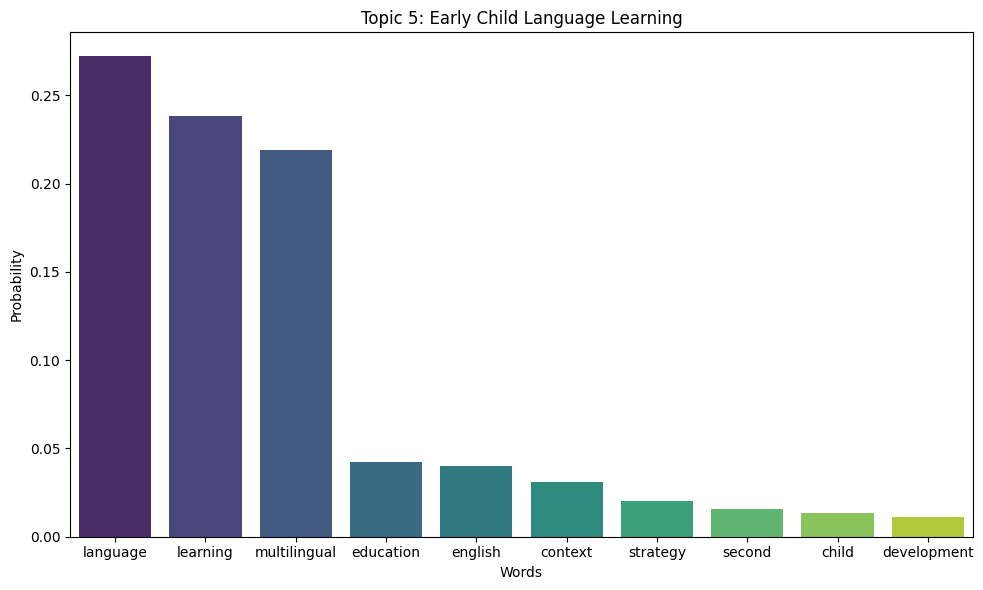


--- Top 10 Words for Topic 10 from 20-topic model ---


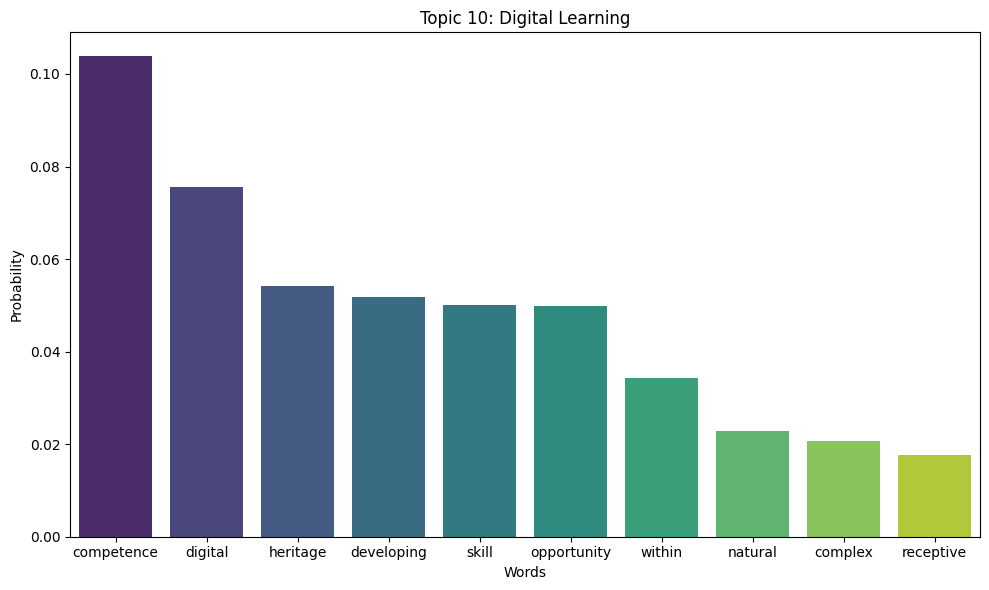


--- Top 10 Words for Topic 15 from 20-topic model ---


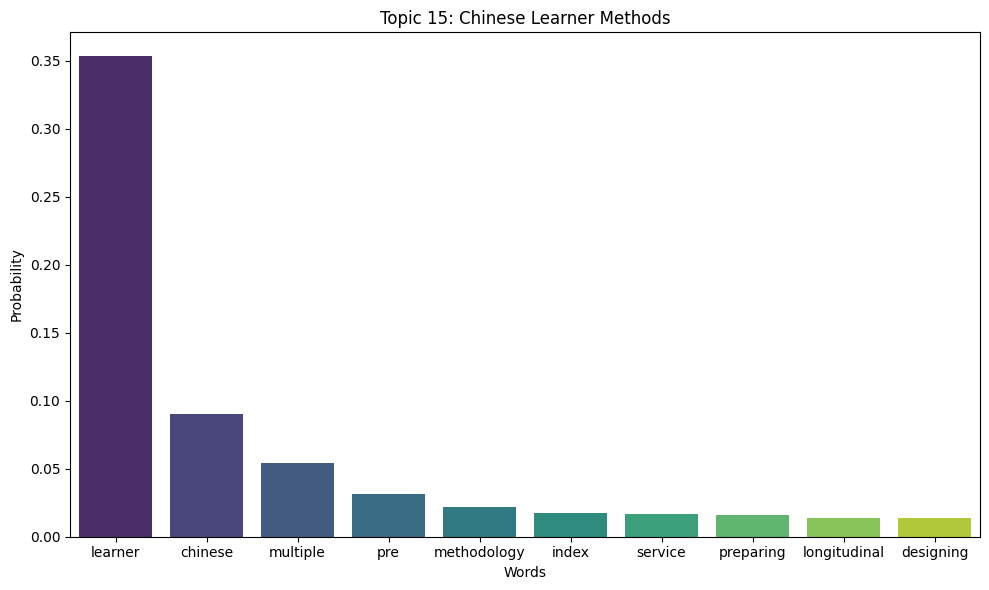


--- Top 10 Words for Topic 19 from 20-topic model ---


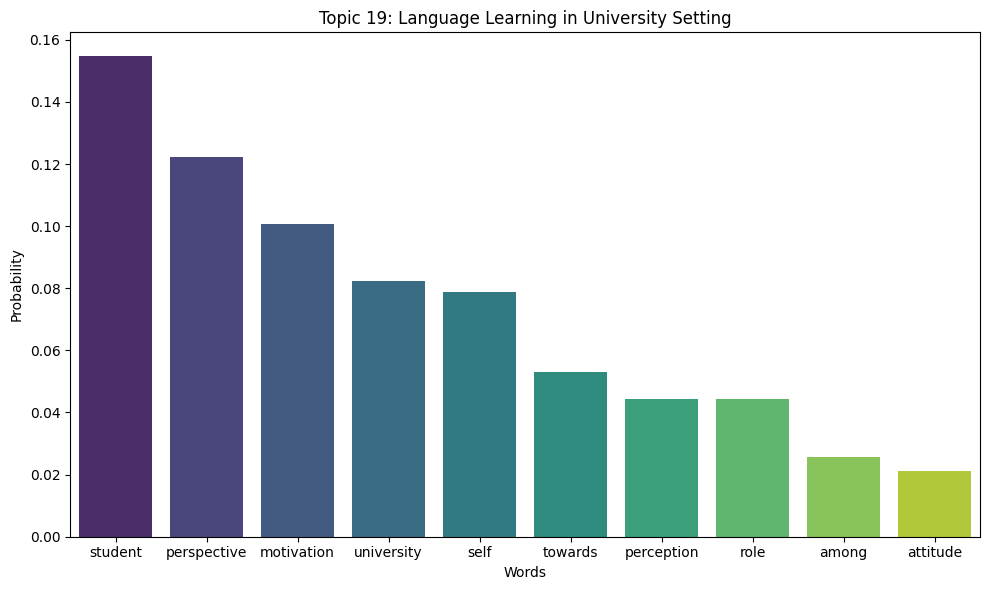

In [18]:
# Function to repeat graph creation
def plot_topic_words_and_label(lda_model, topic_id, dictionary, title, num_words=10):
    print(f"\n--- Top {num_words} Words for Topic {topic_id} from {lda_model.num_topics}-topic model ---")
    top_words = lda_model.show_topic(topic_id, topn=num_words)
    words = [word for word, prob in top_words]
    probabilities = [prob for word, prob in top_words]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=words, y=probabilities, ax=ax, hue=words, legend=False, palette='viridis')
    ax.set_title(f'Topic {topic_id}: {title}')
    ax.set_xlabel('Words')
    ax.set_ylabel('Probability')
    plt.tight_layout()
    plt.show()

# Visualize topics 5, 10, 15 from the 20-topic model
print("--- Visualizing selected topics from the 20-topic model ---")
plot_topic_words_and_label(lda_model_20_topics, 5, dictionary, 'Early Child Language Learning')
plot_topic_words_and_label(lda_model_20_topics, 10, dictionary, 'Digital Learning')
plot_topic_words_and_label(lda_model_20_topics, 15, dictionary, 'Chinese Learner Methods')
plot_topic_words_and_label(lda_model_20_topics, 19, dictionary, 'Language Learning in University Setting')

# Generate interactive graphic for all 20 Topics
vis = pyLDAvis.gensim_models.prepare(lda_model_20_topics, corpus, dictionary)
pyLDAvis.display(vis)

### Analyzation of Visuals

- Disinct topic: From the graphed topic of 5, 10, 15, 20, there is a distinct differnce between the selected topics from one another. There would be overlap is certain type of words but general idea of the words were different in nature.

- Overlap: With few words that have overlap, mostly words relating to what was search from the bibliographic database, topics did not overlap outside of those cases.

- Keywords Aligning: The expected words that were prevelent when I was doing my search from the start is prevelent and did align in expectation. Althrough, what shifted my expectation is how the trends of topics were in a wider range than what I would have expected. This range could be in relation with type of article within the dataset and popular trends relating to research applicable to what was initially searched.

## Task 5: Reflection

Challenges relating to this lab was working outside example code that you would have provided. With this lab being more coding and working with multiple python projects, there was fun in working through the data and having control to shape it how I would have desired from the start. Working through each seaction and changing ways of approch, with challanging myself to become better at utilizing tools which would be common in future career.

The ideas from topic modeling would be helpful in future professions of research within private sector. With many companies utilizing or needing models to analyze large datasets, knowledge and understand connecting to this subject will be useful skills.